# Sugar Crystal Quality Inspection

## Modules

In [4]:
import os
import csv
import torch
import random
import numpy as np

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'Times New Roman'})
plt.rcParams.update({'font.size': 14})

In [6]:
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim

In [8]:
import timm

e:\Studies\MIT\8\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configs

### Random Seed

In [9]:
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

### CUDA Check

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Directory Paths

In [11]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..\\\\.."))
DATA_DIR = os.path.join(ROOT_DIR, "Datasets", "sugar-quality-inspection")
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(DATA_DIR, "test_images")

print(f"""
Train Images Directory: {(TRAIN_IMAGES_DIR, os.path.exists(TRAIN_IMAGES_DIR))}
Test Images Directory: {(TEST_IMAGES_DIR, os.path.exists(TEST_IMAGES_DIR))}
"""
)


Train Images Directory: ('e:\\Studies\\MIT\\8\\Project\\Datasets\\sugar-quality-inspection\\train_images', True)
Test Images Directory: ('e:\\Studies\\MIT\\8\\Project\\Datasets\\sugar-quality-inspection\\test_images', True)



### Image Configs

In [12]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

### Image Transforms

In [13]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

### Training Configs

In [14]:
NUM_CLASSES = 4
MAX_EPOCHS = 50
PATIENCE = 50

### Model Name

In [15]:
MODEL_NAME = "swin_tiny_patch4_window7_224"

### Saving the Model

In [16]:
BEST_MODEL_DIRECTORY = os.path.join(ROOT_DIR, "Models", "Sugar", MODEL_NAME)
print(f"Best Model Directory: {BEST_MODEL_DIRECTORY}")
# Create directory if it doesn't exist
os.makedirs(BEST_MODEL_DIRECTORY, exist_ok=True)
print("Directory created (if it didn't exist):", BEST_MODEL_DIRECTORY)


Best Model Directory: e:\Studies\MIT\8\Project\Models\Sugar\swin_tiny_patch4_window7_224
Directory created (if it didn't exist): e:\Studies\MIT\8\Project\Models\Sugar\swin_tiny_patch4_window7_224


In [17]:
## Fetch latest name of best model from BEST_MODEL_DIRECTORY and increment the number in the name by 1, to create new BEST_MODEL_PATH
existing_models = [f for f in os.listdir(BEST_MODEL_DIRECTORY) if f.endswith(".pth")]
if existing_models:
    existing_models.sort()
    latest_model = existing_models[-1]
    latest_number = int(latest_model.split(".")[0])
    new_number = latest_number + 1
else:
    new_number = 1

In [18]:
BEST_MODEL_PATH = str(new_number) + ".pth"
BEST_MODEL_PATH

'2.pth'

In [19]:
BEST_MODEL_PATH = os.path.join(BEST_MODEL_DIRECTORY, BEST_MODEL_PATH)
BEST_MODEL_PATH = os.path.abspath(BEST_MODEL_PATH)
print("Best model path:", BEST_MODEL_PATH)

Best model path: e:\Studies\MIT\8\Project\Models\Sugar\swin_tiny_patch4_window7_224\2.pth


### Results Directory

In [20]:
RESULTS_DIR = os.path.join(ROOT_DIR, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_FILE = os.path.join(RESULTS_DIR, "model_results_sugar.csv")
print("Results file path:", RESULTS_FILE)

Results file path: e:\Studies\MIT\8\Project\Results\model_results_sugar.csv


### Results Metrics Directory

In [21]:
RESULT_METRICS_DIR = os.path.join(ROOT_DIR, "Results", "Sugar", MODEL_NAME)
os.makedirs(RESULT_METRICS_DIR, exist_ok=True)
print("Result metrics directory:", RESULT_METRICS_DIR)

Result metrics directory: e:\Studies\MIT\8\Project\Results\Sugar\swin_tiny_patch4_window7_224


## Decision Graph

### Domain Knowledge

In [22]:
STATE_TEMPLATES = {
    "unsaturated": {
        "supersaturation_ratio": (0.95, 1.00),
        "nucleation_risk": "none",
        "growth_stability": "none"
    },
    "metastable": {
        "supersaturation_ratio": (1.05, 1.25),
        "nucleation_risk": "low",
        "growth_stability": "stable"
    },
    "intermediate": {
        "supersaturation_ratio": (1.20, 1.35),
        "nucleation_risk": "medium",
        "growth_stability": "transition"
    },
    "labile": {
        "supersaturation_ratio": (1.30, 1.50),
        "nucleation_risk": "high",
        "growth_stability": "unstable"
    }
}

### Confidence-Weighted Inference

In [23]:
def infer_supersaturation_range(crystal_state, confidence):
    low, high = STATE_TEMPLATES[crystal_state]["supersaturation_ratio"]
    center = (low + high) / 2
    width = (high - low) * (1 - confidence)
    return (center - width / 2, center + width / 2)

### Construction of Inferred State

In [24]:
def build_inferred_state(vit_output):
    cs = vit_output["crystal_state"]
    conf = vit_output["confidence"]

    inferred = {
        "crystal_state": cs,
        "confidence": conf,
        "supersaturation_ratio_range": infer_supersaturation_range(cs, conf),
        "nucleation_risk": STATE_TEMPLATES[cs]["nucleation_risk"],
        "growth_stability": STATE_TEMPLATES[cs]["growth_stability"]
    }

    return inferred

### Graph

In [25]:
CDG = nx.DiGraph()

 ### Nodes

In [26]:
nodes = {
    "observed": ["crystal_state"],
    "derived": [
        "supersaturation_ratio_range",
        "nucleation_risk",
        "growth_stability"
    ],
    "action": [
        "reduce_seeding",
        "emergency_dilution",
        "hold_process",
        "increase_evaporation"
    ]
}

for layer, ns in nodes.items():
    for n in ns:
        CDG.add_node(n, layer=layer)

### Edges

In [27]:
CDG.add_edge("crystal_state", "supersaturation_ratio_range")
CDG.add_edge("crystal_state", "nucleation_risk")
CDG.add_edge("crystal_state", "growth_stability")

CDG.add_edge("nucleation_risk", "reduce_seeding")
CDG.add_edge("nucleation_risk", "emergency_dilution")
CDG.add_edge("growth_stability", "hold_process")
CDG.add_edge("growth_stability", "increase_evaporation")


### Endpoint Decisions

In [28]:
def decide_actions(derived_state):
    actions = []

    if derived_state["nucleation_risk"] == "high":
        actions.append("reduce_seeding")
        actions.append("emergency_dilution")

    if derived_state["growth_stability"] == "stable":
        actions.append("hold_process")
    else:
        actions.append("increase_evaporation")

    return actions

### Visualization

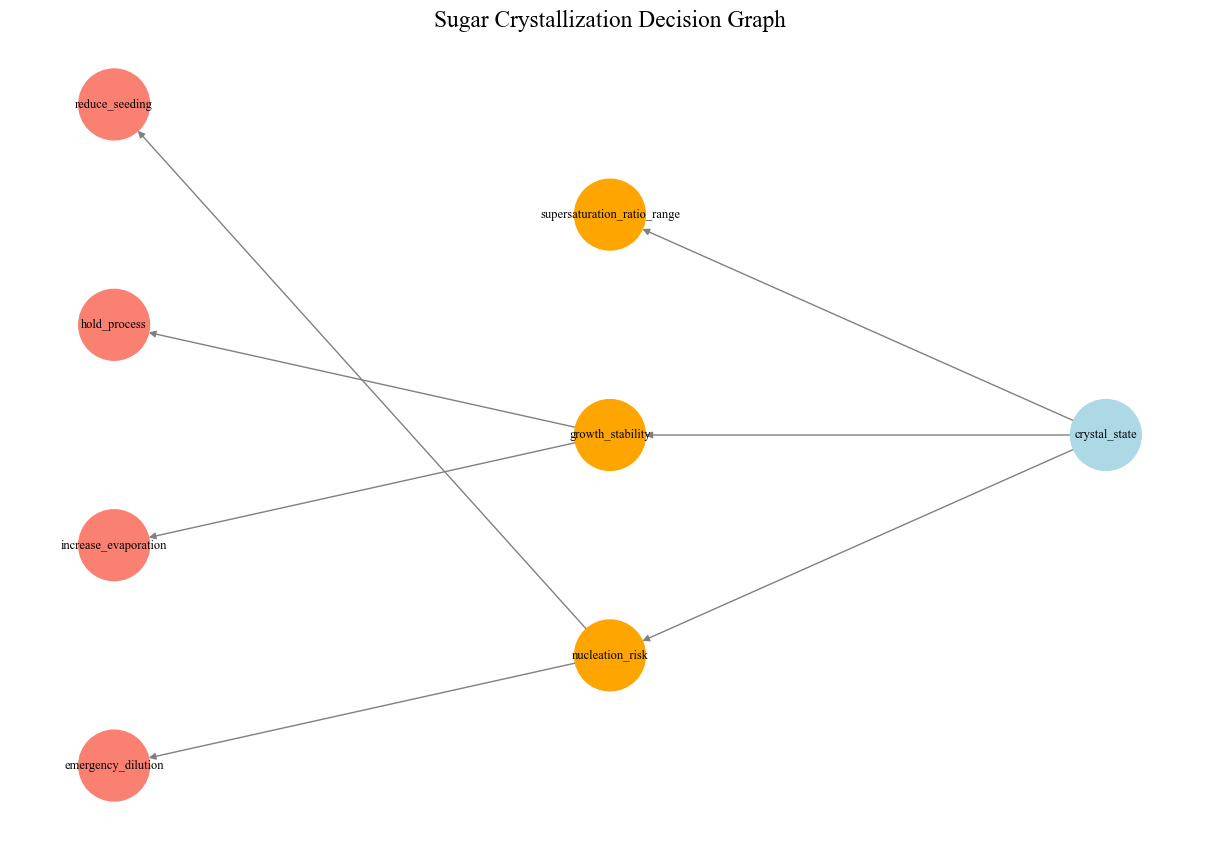

In [29]:
pos = nx.multipartite_layout(CDG, subset_key="layer")

color_map = []
for n in CDG.nodes():
    layer = CDG.nodes[n]["layer"]
    if layer == "observed":
        color_map.append("lightblue")
    elif layer == "derived":
        color_map.append("orange")
    else:
        color_map.append("salmon")

plt.figure(figsize=(12, 8))
nx.draw(
    CDG,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2600,
    font_size=9,
    edge_color="gray"
)
plt.title("Sugar Crystallization Decision Graph")
plt.show()

### Sample Run - Without ViT

In [30]:
vit_output = {
    "crystal_state": "labile",
    "confidence": 0.87
}

In [31]:
kg_input_state = build_inferred_state(vit_output)
kg_input_state

{'crystal_state': 'labile',
 'confidence': 0.87,
 'supersaturation_ratio_range': (1.387, 1.4129999999999998),
 'nucleation_risk': 'high',
 'growth_stability': 'unstable'}

In [32]:
final_actions = decide_actions(kg_input_state)
final_actions

['reduce_seeding', 'emergency_dilution', 'increase_evaporation']

## State Transition Graph

In [33]:
# crystallization_state_graph
CSG = nx.DiGraph()

### Nodes

In [34]:
CSG.add_node(
    "UNSATURATED",
    sigma_range=(0.95, 1.00),
    nucleation="none",
    growth="none",
    visual="clear_liquid"
)

CSG.add_node(
    "METASTABLE",
    sigma_range=(1.05, 1.25),
    nucleation="low",
    growth="controlled",
    visual="clear_with_crystals"
)

CSG.add_node(
    "INTERMEDIATE",
    sigma_range=(1.20, 1.35),
    nucleation="medium",
    growth="mixed",
    visual="cloudy"
)

CSG.add_node(
    "LABILE",
    sigma_range=(1.30, 1.50),
    nucleation="high",
    growth="uncontrolled",
    visual="opaque_fines"
)

### Edges

In [35]:
CSG.add_edge(
    "UNSATURATED",
    "METASTABLE",
    trigger="supersaturation_increase",
    risk="low",
    controllability="high"
)

CSG.add_edge(
    "METASTABLE",
    "INTERMEDIATE",
    trigger="excess_evaporation",
    risk="medium",
    controllability="medium"
)

CSG.add_edge(
    "INTERMEDIATE",
    "LABILE",
    trigger="runaway_supersaturation",
    risk="high",
    controllability="low"
)

CSG.add_edge(
    "LABILE",
    "INTERMEDIATE",
    trigger="dilution_or_cooling",
    risk="medium",
    controllability="medium"
)

CSG.add_edge(
    "INTERMEDIATE",
    "METASTABLE",
    trigger="stabilized_growth",
    risk="low",
    controllability="high"
)

### Transitions

In [36]:
def score_transitions(graph, active_state):
    scores = {}

    for _, dst, data in graph.out_edges(active_state, data=True):
        risk_weight = {"low": 0.2, "medium": 0.5, "high": 0.8}[data["risk"]]
        controllability = {"high": 0.9, "medium": 0.6, "low": 0.3}[data["controllability"]]

        scores[dst] = risk_weight * (1 - controllability)

    return scores

### Visualization

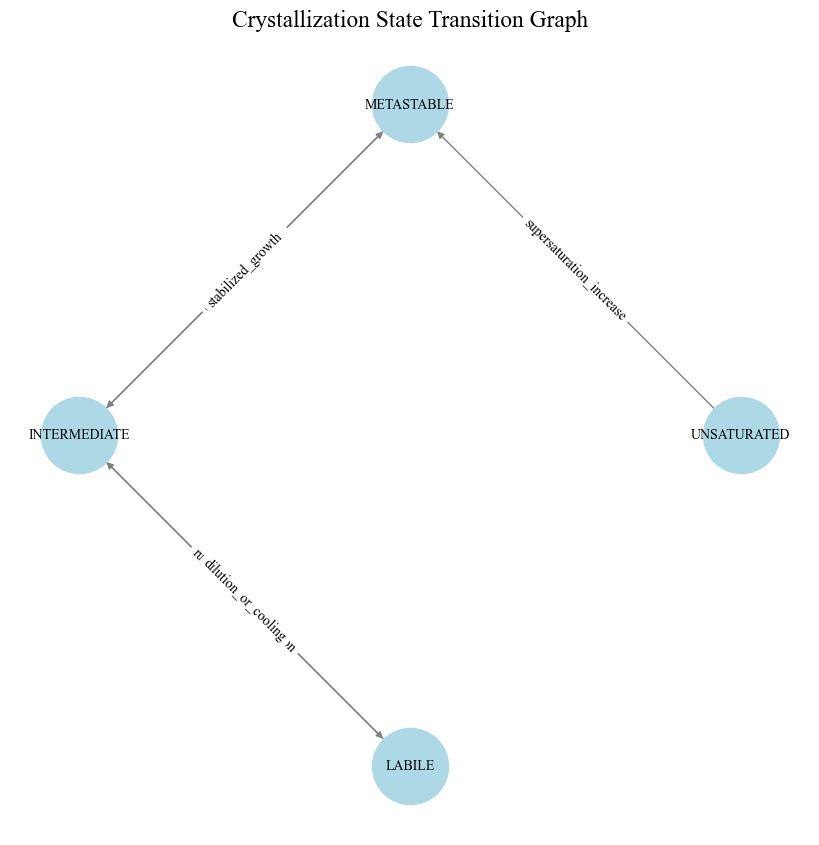

In [37]:
pos = nx.circular_layout(CSG)

plt.figure(figsize=(8, 8))
nx.draw(
    CSG,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    edge_color="gray"
)

edge_labels = {
    (u, v): d["trigger"]
    for u, v, d in CSG.edges(data=True)
}

nx.draw_networkx_edge_labels(CSG, pos, edge_labels=edge_labels)

plt.title("Crystallization State Transition Graph")
plt.show()


### Sample Run - Without ViT

In [38]:
vit_output = {
    "predicted_state": "LABILE",
    "confidence": 0.87
}

In [39]:
for node in CSG.nodes():
    CSG.nodes[node]["belief"] = 0.0

CSG.nodes[vit_output["predicted_state"]]["belief"] = vit_output["confidence"]

In [40]:
transition_scores = score_transitions(CSG, "LABILE")
transition_scores

{'INTERMEDIATE': 0.2}

## Final Knowledge Graph

In [41]:
KG = nx.DiGraph()

### States

In [42]:
states = {
    "UNSATURATED": {
        "sigma_range": (0.95, 1.00),
        "description": "No crystal growth possible"
    },
    "METASTABLE": {
        "sigma_range": (1.05, 1.25),
        "description": "Controlled crystal growth zone"
    },
    "INTERMEDIATE": {
        "sigma_range": (1.20, 1.35),
        "description": "Transition regime"
    },
    "LABILE": {
        "sigma_range": (1.30, 1.50),
        "description": "Uncontrolled nucleation regime"
    }
}

### Conditions

In [43]:
conditions = [
    "low_nucleation_risk",
    "medium_nucleation_risk",
    "high_nucleation_risk",
    "stable_growth",
    "unstable_growth"
]

### Actions

In [44]:
actions = [
    "hold_process",
    "increase_evaporation",
    "reduce_seeding",
    "emergency_dilution"
]

### Add Nodes, Conditions, Actions

In [45]:
for s, attrs in states.items():
    KG.add_node(s, node_type="state", **attrs)
for c in conditions:
    KG.add_node(c, node_type="condition")
for a in actions:
    KG.add_node(a, node_type="action")

### Edges - State Transitions

In [46]:
KG.add_edge("UNSATURATED", "METASTABLE",
            edge_type="state_transition",
            trigger="increase_supersaturation")

KG.add_edge("METASTABLE", "INTERMEDIATE",
            edge_type="state_transition",
            trigger="excess_evaporation")

KG.add_edge("INTERMEDIATE", "LABILE",
            edge_type="state_transition",
            trigger="runaway_supersaturation")

KG.add_edge("LABILE", "INTERMEDIATE",
            edge_type="state_transition",
            trigger="cooling_or_dilution")

KG.add_edge("INTERMEDIATE", "METASTABLE",
            edge_type="state_transition",
            trigger="growth_stabilization")

### Edges - Condition Inference

In [47]:
KG.add_edge("UNSATURATED", "low_nucleation_risk", edge_type="implies_condition")
KG.add_edge("METASTABLE", "low_nucleation_risk", edge_type="implies_condition")
KG.add_edge("METASTABLE", "stable_growth", edge_type="implies_condition")

KG.add_edge("INTERMEDIATE", "medium_nucleation_risk", edge_type="implies_condition")
KG.add_edge("INTERMEDIATE", "unstable_growth", edge_type="implies_condition")

KG.add_edge("LABILE", "high_nucleation_risk", edge_type="implies_condition")
KG.add_edge("LABILE", "unstable_growth", edge_type="implies_condition")

### Edges - Actions

In [48]:
KG.add_edge("low_nucleation_risk", "hold_process",
            edge_type="triggers_action")

KG.add_edge("stable_growth", "hold_process",
            edge_type="triggers_action")

KG.add_edge("unstable_growth", "increase_evaporation",
            edge_type="triggers_action")

KG.add_edge("high_nucleation_risk", "reduce_seeding",
            edge_type="triggers_action")

KG.add_edge("high_nucleation_risk", "emergency_dilution",
            edge_type="triggers_action")

### Action Inference

In [49]:
def infer_actions(graph, active_state):
    actions = set()

    for _, cond in graph.out_edges(active_state):
        if graph.nodes[cond]["node_type"] == "condition":
            for _, act in graph.out_edges(cond):
                if graph.nodes[act]["node_type"] == "action":
                    actions.add(act)

    return list(actions)

### Sample Run - Without ViT

In [50]:
vit_output = {
    "state": "LABILE",
    "confidence": 0.87
}

In [51]:
for n in KG.nodes():
    KG.nodes[n]["belief"] = 0.0

KG.nodes[vit_output["state"]]["belief"] = vit_output["confidence"]

In [52]:
final_actions = infer_actions(KG, vit_output["state"])
final_actions

['emergency_dilution', 'increase_evaporation', 'reduce_seeding']

### Visualization

In [53]:
pos = nx.spring_layout(KG, seed=42)

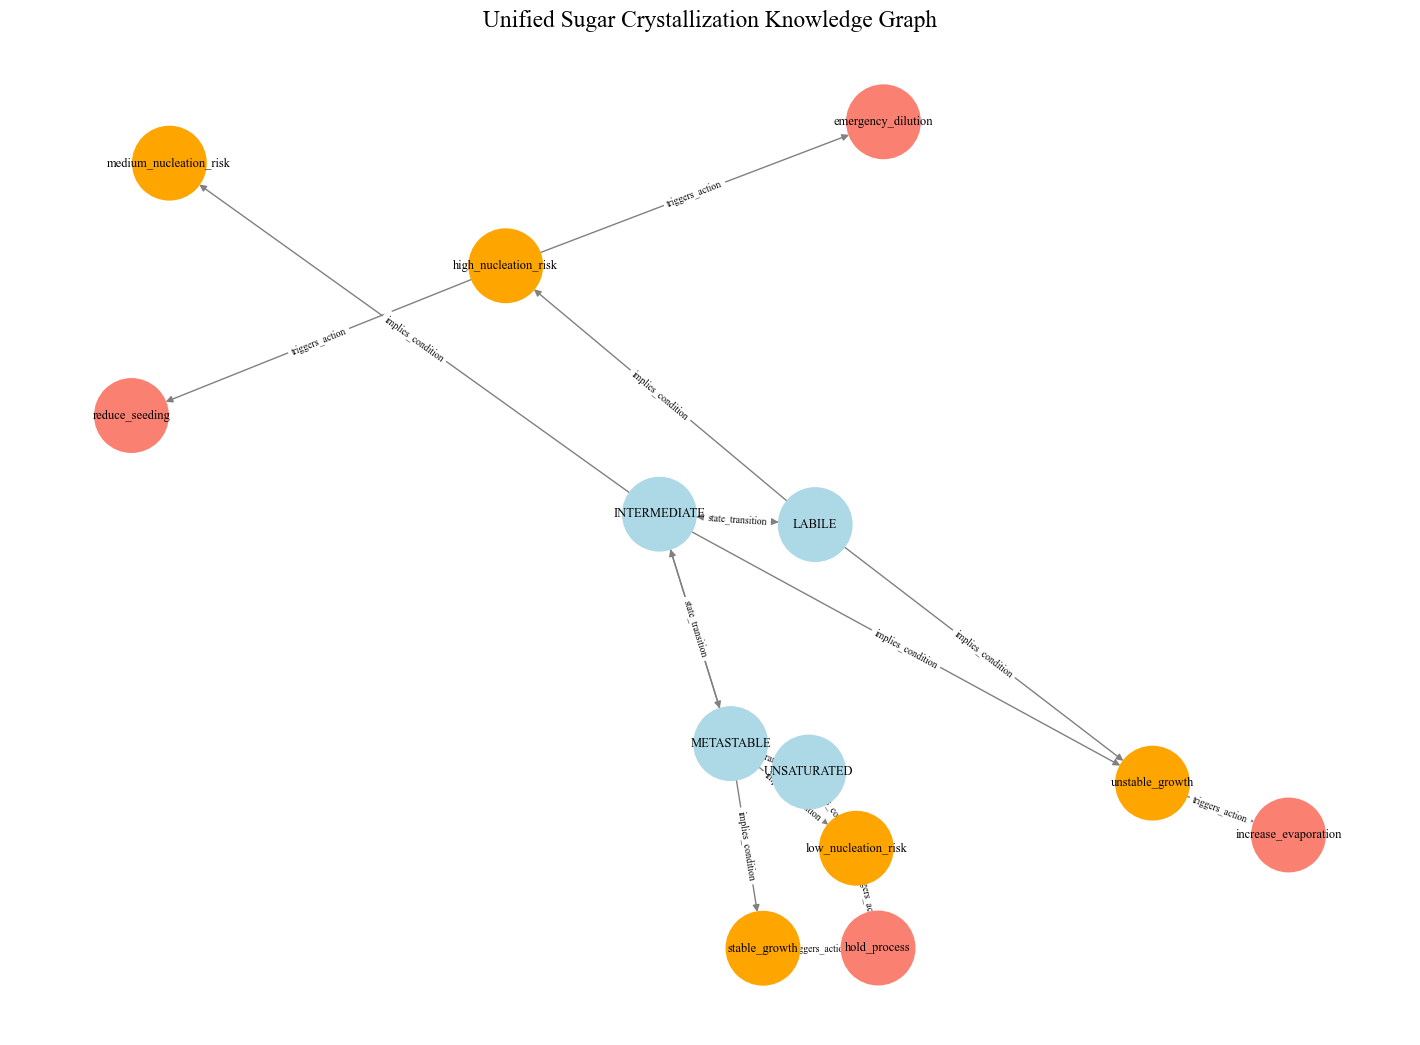

In [54]:
color_map = []
for n in KG.nodes():
    t = KG.nodes[n]["node_type"]
    if t == "state":
        color_map.append("lightblue")
    elif t == "condition":
        color_map.append("orange")
    else:
        color_map.append("salmon")

plt.figure(figsize=(14, 10))
nx.draw(
    KG,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2800,
    font_size=9,
    edge_color="gray"
)

edge_labels = {
    (u, v): d["edge_type"]
    for u, v, d in KG.edges(data=True)
}

nx.draw_networkx_edge_labels(KG, pos, edge_labels=edge_labels, font_size=7)

plt.title("Unified Sugar Crystallization Knowledge Graph")
plt.show()


### Better Layout

In [55]:
def layered_layout(graph):
    pos = {}

    x_pos = {
        "state": 0.0,
        "condition": 1.5,
        "action": 3.0
    }

    layers = {"state": [], "condition": [], "action": []}
    for n, d in graph.nodes(data=True):
        layers[d["node_type"]].append(n)

    for layer, nodes in layers.items():
        y_spacing = 1.0
        start_y = -(len(nodes) - 1) / 2

        for i, node in enumerate(sorted(nodes)):
            pos[node] = (x_pos[layer], start_y + i * y_spacing)

    return pos

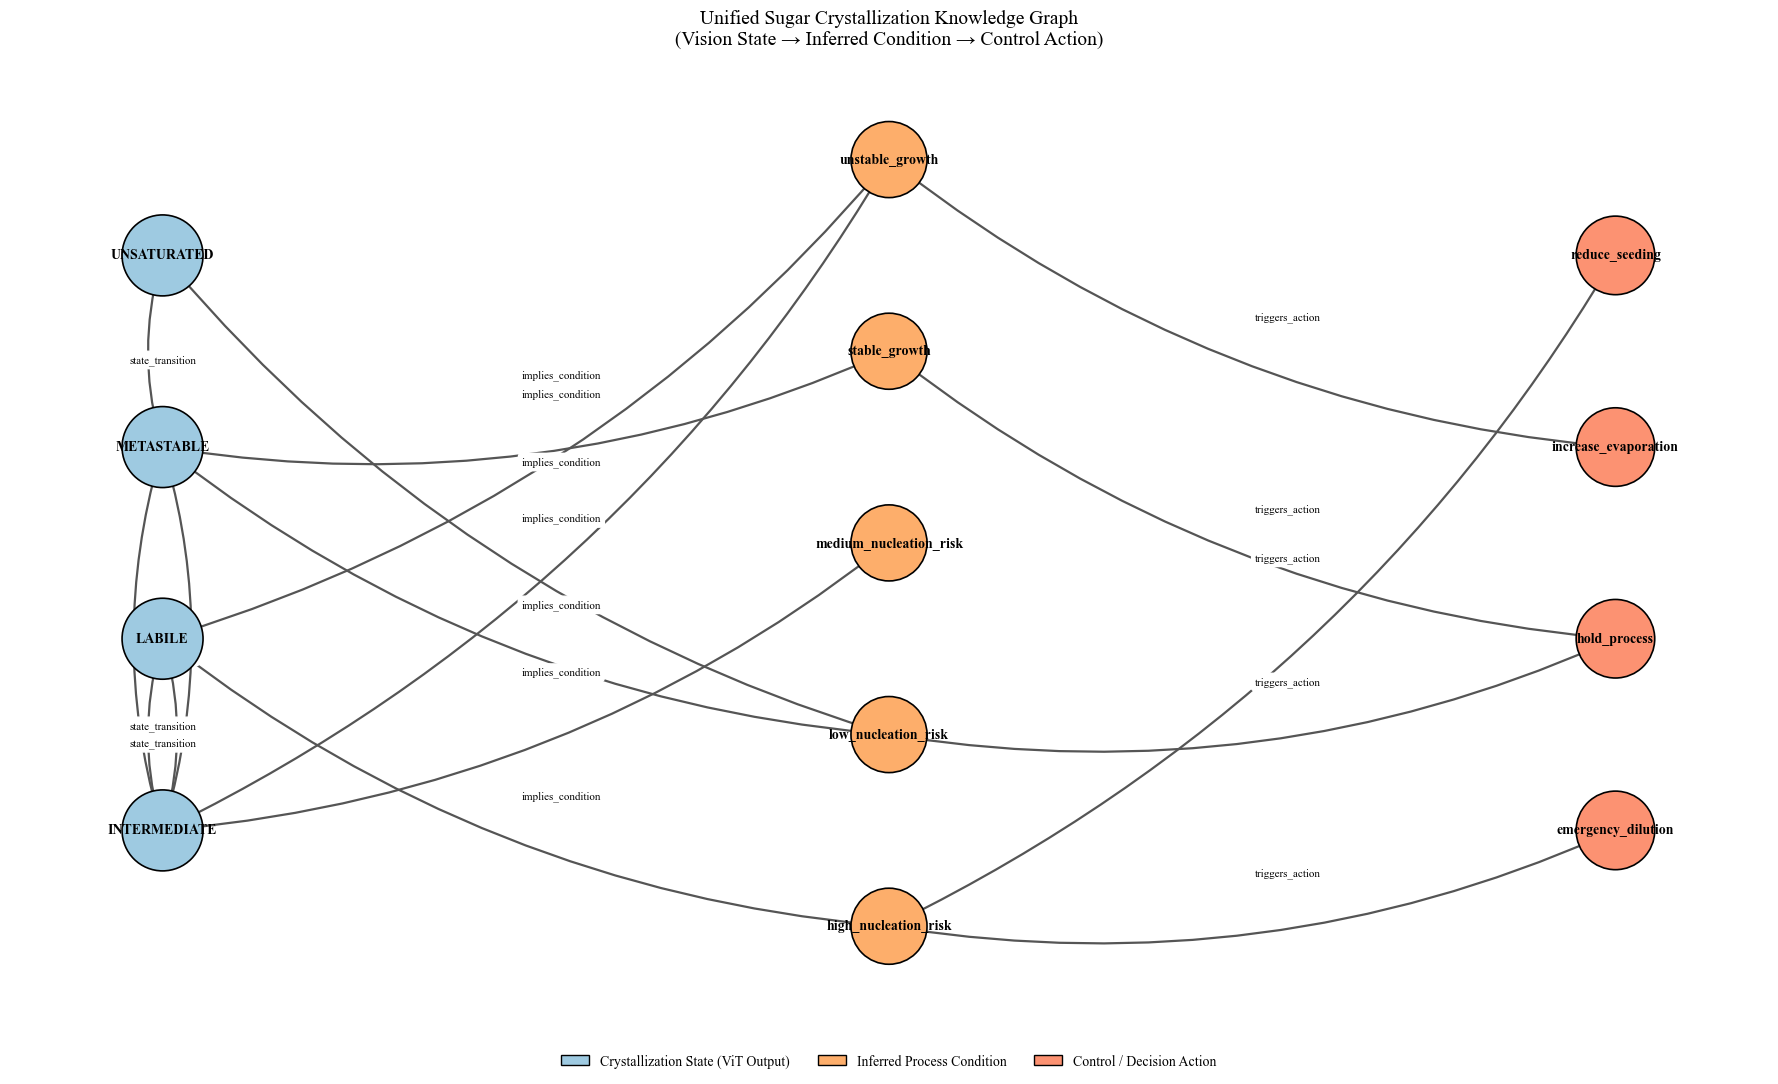

In [56]:
pos = layered_layout(KG)

plt.figure(figsize=(18, 11))

node_colors = []
node_sizes = []

for n in KG.nodes():
    t = KG.nodes[n]["node_type"]
    if t == "state":
        node_colors.append("#9ecae1") 
        node_sizes.append(3400)
    elif t == "condition":
        node_colors.append("#fdae6b")
        node_sizes.append(3000)
    else:
        node_colors.append("#fc9272")
        node_sizes.append(3200)

nx.draw_networkx_nodes(
    KG,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_edges(
    KG,
    pos,
    arrowstyle="->",
    arrowsize=18,
    edge_color="#555555",
    width=1.6,
    connectionstyle="arc3,rad=0.15"
)

nx.draw_networkx_labels(
    KG,
    pos,
    font_size=10,
    font_weight="bold"
)

edge_labels = {
    (u, v): d["edge_type"]
    for u, v, d in KG.edges(data=True)
}

nx.draw_networkx_edge_labels(
    KG,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.55,
    rotate=False
)

plt.title(
    "Unified Sugar Crystallization Knowledge Graph\n"
    "(Vision State → Inferred Condition → Control Action)",
    fontsize=14,
    pad=25
)


legend_elements = [
    Patch(facecolor="#9ecae1", edgecolor="black",
          label="Crystallization State (ViT Output)"),
    Patch(facecolor="#fdae6b", edgecolor="black",
          label="Inferred Process Condition"),
    Patch(facecolor="#fc9272", edgecolor="black",
          label="Control / Decision Action")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.axis("off")
plt.tight_layout()

## Save the graph visualization to Media (as Sugar_Crystallization_KG.png)
output_path = os.path.join(ROOT_DIR, "Media", "Sugar_Crystallization_KG.png")
plt.savefig(output_path)

plt.show()

## Dataset

### Image Count - Train Dataset

In [57]:
full_train_dataset = datasets.ImageFolder(
    root=TRAIN_IMAGES_DIR,
    transform=train_transforms
)

class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Total train images:", len(full_train_dataset))
print("Number of classes:", NUM_CLASSES)

Classes: ['intermediate', 'labile', 'metastable', 'unsaturated']
Total train images: 800
Number of classes: 4


### Image Count - Test Dataset

In [58]:
test_dataset = datasets.ImageFolder(
    root=TEST_IMAGES_DIR,
    transform=val_test_transforms
)

print("Total test images:", len(test_dataset))

Total test images: 200


### Train-Validation Split

In [59]:
total_size = len(full_train_dataset)

train_size = int(0.70 * total_size)
val_size   = total_size - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(random_seed)
)

### Dataloaders

In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### After Batch Division

In [61]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## Model

### Fetch Required Model

In [62]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

### Move to GPU

In [63]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


### Verify Classification Head

In [64]:
def print_classifier_head(model):
    if hasattr(model, "head"):
        print("Classifier head:", model.head)
    elif hasattr(model, "fc"):
        print("Classifier head:", model.fc)
    elif hasattr(model, "classifier"):
        print("Classifier head:", model.classifier)
    else:
        print("Classifier head not found")

print_classifier_head(model)

Classifier head: ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=4, bias=True)
  (flatten): Identity()
)


### Trainable Parameters

In [65]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 27,522,430
Trainable parameters: 27,522,430


## Training

### Loss Function

In [66]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [67]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4 # weight decay --> improves regularization!
)

### Train Function

In [68]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Validate Function

In [69]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Training Loop

In [70]:
best_val_acc = 0.0
epochs_without_improvement = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print(
    f"{'Epoch':<8}"
    f"{'Train Loss':<15}"
    f"{'Val Loss':<15}"
    f"{'Train Acc':<12}"
    f"{'Val Acc':<12}"
    f"{'Status':<20}"
)

print("-" * 85)

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        status = "New Best Model"

    else:

        epochs_without_improvement += 1
        status = f"No Improvement ({epochs_without_improvement}/{PATIENCE})"


    # ---------- Tabular logging ----------
    print(
        f"{epoch:<8}"
        f"{train_loss:<15.4f}"
        f"{val_loss:<15.4f}"
        f"{train_acc:<12.4f}"
        f"{val_acc:<12.4f}"
        f"{status:<20}"
    )


    # ---------- Early stopping ----------
    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Best validation accuracy: {best_val_acc:.4f}")
        break

Epoch   Train Loss     Val Loss       Train Acc   Val Acc     Status              
-------------------------------------------------------------------------------------
1       0.6997         1.1650         0.7250      0.6292      New Best Model      
2       0.6167         0.2518         0.7857      0.9292      New Best Model      
3       0.1753         0.3125         0.9321      0.9250      No Improvement (1/50)
4       0.2073         0.2459         0.9250      0.8958      No Improvement (2/50)
5       0.1237         0.1722         0.9643      0.9417      New Best Model      
6       0.0580         0.2617         0.9839      0.9333      No Improvement (1/50)
7       0.1092         0.2235         0.9661      0.9333      No Improvement (2/50)
8       0.0717         0.1984         0.9696      0.9375      No Improvement (3/50)
9       0.1147         0.1812         0.9589      0.9292      No Improvement (4/50)
10      0.0680         0.2161         0.9804      0.9417      No Improvement (

## Results

### Load Best Model

In [71]:
# Load best model for testing
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

### Accuracy

In [72]:
print("Accuracy = {:.4f}".format(best_val_acc))

Accuracy = 0.9708


### Accuracy and Loss Curves

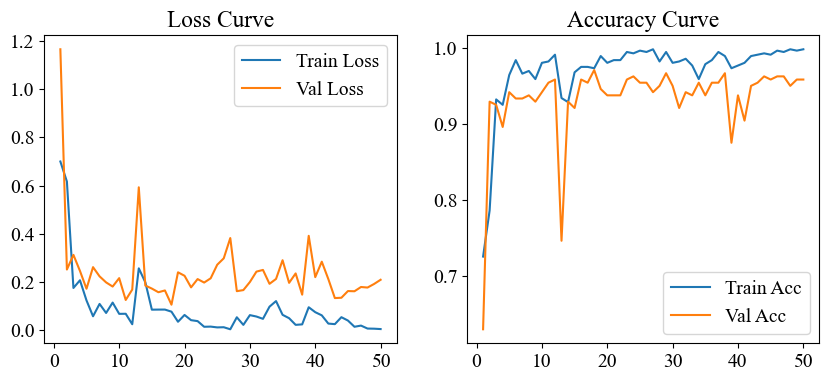

In [73]:
epochs_trained = len(train_losses)
epochs_range = range(1, epochs_trained + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

### Predict on Test Set

In [74]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [75]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
print("Test Accuracy: {:.2f}%".format(accuracy))

Test Accuracy: 83.00%


### Confusion Matrix

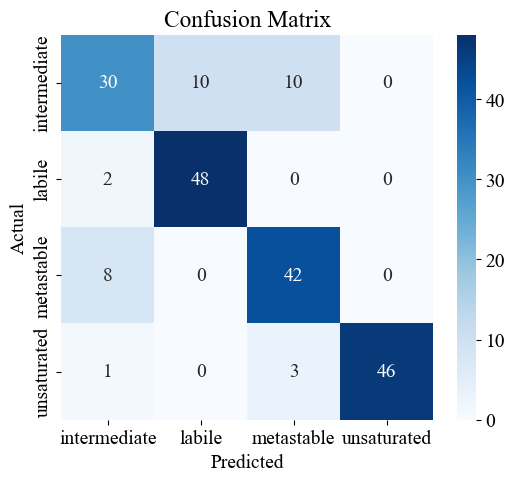

In [76]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

output_path = os.path.join(RESULT_METRICS_DIR, "confusion_matrix.png")
plt.savefig(output_path)

plt.show()

### Classification Report

In [77]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

# Write report to .txt file in RESULT_METRICS_DIR with name classification_report.txt
report_path = os.path.join(RESULT_METRICS_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

Classification Report:

              precision    recall  f1-score   support

intermediate     0.7317    0.6000    0.6593        50
      labile     0.8276    0.9600    0.8889        50
  metastable     0.7636    0.8400    0.8000        50
 unsaturated     1.0000    0.9200    0.9583        50

    accuracy                         0.8300       200
   macro avg     0.8307    0.8300    0.8266       200
weighted avg     0.8307    0.8300    0.8266       200



### Add Results to CSV

In [78]:
row = [
    MODEL_NAME,
    round(best_val_acc, 5),
    round(val_losses[val_accuracies.index(best_val_acc)], 5),
    round(accuracy, 2),
    epochs_trained
]

file_exists = os.path.isfile(RESULTS_FILE)

with open(RESULTS_FILE, mode="a", newline="") as f:
    writer = csv.writer(f)

    # Write header only once
    if not file_exists:
        writer.writerow([
            "model_name",
            "best_val_accuracy",
            "best_val_loss",
            "test_accuracy",
            "epochs_trained"
        ])

    writer.writerow(row)

print(f"Results logged successfully to {RESULTS_FILE}.")
print("Logged row:", row)

Results logged successfully to e:\Studies\MIT\8\Project\Results\model_results_sugar.csv.
Logged row: ['swin_tiny_patch4_window7_224', 0.97083, 0.10602, np.float64(83.0), 50]
